In [2]:
import geopandas as gpd

# Load grid lines and borders
lines_gdf = gpd.read_file("qgis/lines_aut.shp")
borders_gdf = gpd.read_file("qgis/Grenze.shp")

# Make sure everything is in the same CRS
lines_gdf = lines_gdf.to_crs(borders_gdf.crs)

In [3]:
austria_polygon = borders_gdf.unary_union  # one big polygon of Austria

/tmp/ipykernel_1275714/1110057112.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  austria_polygon = borders_gdf.unary_union  # one big polygon of Austria


In [4]:
from shapely.geometry import Point, LineString

def is_true_cross_border(line: LineString, polygon) -> bool:
    start, end = Point(line.coords[0]), Point(line.coords[-1])
    inside_start = polygon.contains(start)
    inside_end = polygon.contains(end)
    return inside_start != inside_end  # True if only one end is inside Austria

# Apply filter
cross_border_lines = lines_gdf[lines_gdf.geometry.apply(lambda g: is_true_cross_border(g, austria_polygon))]

AttributeError: 'NoneType' object has no attribute 'coords'

In [5]:
# Step 1: Filter out None geometries
valid_lines_gdf = lines_gdf[lines_gdf.geometry.notnull()].copy()

# Optional: Also drop zero-length lines or non-LineString geometries
valid_lines_gdf = valid_lines_gdf[valid_lines_gdf.geometry.apply(lambda g: isinstance(g, LineString) and len(g.coords) >= 2)]

# Step 2: Apply the cross-border test
def is_true_cross_border(line: LineString, polygon) -> bool:
    start, end = Point(line.coords[0]), Point(line.coords[-1])
    inside_start = polygon.contains(start)
    inside_end = polygon.contains(end)
    return inside_start != inside_end  # True if only one end is inside Austria

# Step 3: Filter
cross_border_lines = valid_lines_gdf[valid_lines_gdf.geometry.apply(lambda g: is_true_cross_border(g, austria_polygon))]


In [7]:
cross_border_lines.

24       5643.062176
37       5792.472053
38       2808.725449
46      33715.242520
91      20836.600745
92      13574.931743
93      13583.412809
97       7254.647423
106      5639.042723
109     14514.560066
178      2511.761914
225     18388.833068
357      2478.917402
1008     9690.503725
1011    12022.160770
1036     3250.410967
1037    10170.436858
1134    11676.599062
1135    11676.599062
1161    14600.387932
1188     9218.935345
1361     8863.285378
1406    26224.134689
1433    24431.202273
1437    24434.194973
1455     1212.221609
1494    63828.984077
1496    22897.601989
1523    19747.088423
1557    13983.768800
1558    13983.741262
1596    53832.103409
1625    53826.070186
1635     8857.814406
1646    33716.469798
1647    33715.875437
1651    31237.413307
1656    31237.413307
1662    47036.497159
1663    47040.723778
1673    23677.947058
1681    62634.943845
1682    62704.063550
1699     3010.441144
1700     3010.441144
1701     2217.758082
1707    23684.688540
1708     2217

In [8]:
import pypsa

n = pypsa.Network("../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc")


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


In [9]:
pypsa_lines = n.lines
pypsa_buses = n.buses


In [10]:
import pandas as pd
from shapely.geometry import LineString

def get_lines_with_coords(n):
    line_data = []
    for line_id, line in n.lines.iterrows():
        bus0 = n.buses.loc[line.bus0]
        bus1 = n.buses.loc[line.bus1]
        # Some networks use lon/lat instead of x/y
        if "x" in bus0 and "y" in bus0:
            p0 = (bus0.x, bus0.y)
            p1 = (bus1.x, bus1.y)
        else:
            p0 = (bus0.lon, bus0.lat)
            p1 = (bus1.lon, bus1.lat)
        line_data.append({
            "name": line_id,
            "bus0": line.bus0,
            "bus1": line.bus1,
            "geometry": LineString([p0, p1])
        })
    return pd.DataFrame(line_data)

pypsa_line_df = get_lines_with_coords(n)
pypsa_line_gdf = gpd.GeoDataFrame(pypsa_line_df, geometry="geometry", crs="EPSG:4326")


In [11]:
lines_gdf = lines_gdf.to_crs("EPSG:4326")  # WGS84 to match PyPSA


In [12]:
from shapely.geometry import LineString

# Optional: round coordinates to avoid floating-point mismatches
def round_line_coords(line, precision=5):
    return LineString([(round(x, precision), round(y, precision)) for x, y in line.coords])

cross_border_lines["rounded_geometry"] = cross_border_lines.geometry.apply(round_line_coords)
pypsa_line_gdf["rounded_geometry"] = pypsa_line_gdf.geometry.apply(round_line_coords)

# Compare via set intersection
shapefile_lines_set = set(cross_border_lines.rounded_geometry)
pypsa_lines_set = set(pypsa_line_gdf.rounded_geometry)

intersection = shapefile_lines_set & pypsa_lines_set
only_in_pypsa = pypsa_lines_set - shapefile_lines_set
only_in_shapefile = shapefile_lines_set - pypsa_lines_set

print(f"Lines in both: {len(intersection)}")
print(f"Only in PyPSA: {len(only_in_pypsa)}")
print(f"Only in shapefile: {len(only_in_shapefile)}")


Lines in both: 0
Only in PyPSA: 207
Only in shapefile: 48


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [13]:
cross_border_lines["geometry"] = cross_border_lines.geometry.buffer(0.01)
joined = gpd.sjoin(pypsa_line_gdf, cross_border_lines, how="inner", predicate="intersects")


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_1275714/894939311.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:31287

  joined = gpd.sjoin(pypsa_line_gdf, cross_border_lines, how="inner", predicate="intersects")


In [14]:
austria_polygon = gpd.read_file("path_to_austria_shapefile.geojson").unary_union


DataSourceError: path_to_austria_shapefile.geojson: No such file or directory

In [15]:
austria_polygon = gpd.GeoSeries([austria_polygon], crs="EPSG:4326").unary_union


/tmp/ipykernel_1275714/342956879.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  austria_polygon = gpd.GeoSeries([austria_polygon], crs="EPSG:4326").unary_union


In [16]:
pypsa_line_df = get_lines_with_coords(n)
pypsa_line_gdf = gpd.GeoDataFrame(pypsa_line_df, geometry="geometry", crs="EPSG:4326")


In [29]:
def is_within_austria(geometry):
    return austria_polygon.contains(geometry)

def is_cross_border(geometry):
    start, end = Point(geometry.coords[0]), Point(geometry.coords[-1])
    in_start = austria_polygon.contains(start)
    in_end = austria_polygon.contains(end)
    return in_start != in_end  # True if one inside, one outside

# Add columns
pypsa_line_gdf["within_austria"] = pypsa_line_gdf.geometry.apply(is_within_austria)
pypsa_line_gdf["cross_border"] = pypsa_line_gdf.geometry.apply(is_cross_border)

# Now you can filter:
austrian_lines = pypsa_line_gdf[pypsa_line_gdf["within_austria"]]
true_cross_border_lines = pypsa_line_gdf[pypsa_line_gdf["cross_border"]]


In [30]:
def is_true_cross_border(line):
    start, end = Point(line.coords[0]), Point(line.coords[-1])
    return austria_polygon.contains(start) != austria_polygon.contains(end)

true_cross_border_lines = pypsa_line_gdf[pypsa_line_gdf.geometry.apply(is_true_cross_border)]


In [32]:
from shapely.geometry import LineString

# Filter both GeoDataFrames to only contain LineStrings
cross_border_lines = cross_border_lines[cross_border_lines.geometry.type == "LineString"]
true_cross_border_lines = true_cross_border_lines[true_cross_border_lines.geometry.type == "LineString"]

def round_line_coords(line, precision=5):
    return LineString([(round(x, precision), round(y, precision)) for x, y in line.coords])

cross_border_lines["rounded"] = cross_border_lines.geometry.apply(round_line_coords)
true_cross_border_lines["rounded"] = true_cross_border_lines.geometry.apply(round_line_coords)

set_a = set(cross_border_lines["rounded"])
set_b = set(true_cross_border_lines["rounded"])

print("✅ Common lines:", len(set_a & set_b))
print("❌ Only in shapefile:", len(set_a - set_b))
print("❌ Only in PyPSA:", len(set_b - set_a))


✅ Common lines: 0
❌ Only in shapefile: 0
❌ Only in PyPSA: 0


ValueError: aspect must be finite and positive 

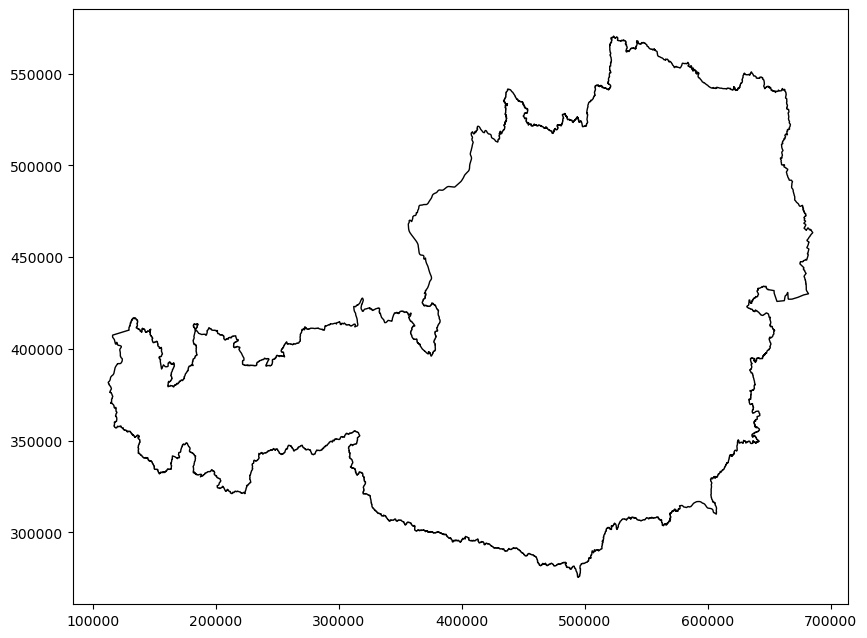

In [27]:
import matplotlib.pyplot as plt

gdf_a = gpd.GeoDataFrame(geometry=list(set_a - set_b), crs="EPSG:4326")
gdf_b = gpd.GeoDataFrame(geometry=list(set_b - set_a), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))
austria_polygon_gdf = gpd.GeoDataFrame(geometry=[austria_polygon], crs="EPSG:4326")
austria_polygon_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
gdf_a.plot(ax=ax, color="red", label="Only in shapefile")
gdf_b.plot(ax=ax, color="blue", label="Only in PyPSA")
plt.legend()
plt.title("Cross-border line mismatches")
plt.show()


In [23]:
print("gdf_a empty?", gdf_a.empty)
print("gdf_b empty?", gdf_b.empty)


gdf_a empty? True
gdf_b empty? True


In [24]:
print("cross_border_lines.crs:", cross_border_lines.crs)
print("true_cross_border_lines.crs:", true_cross_border_lines.crs)


cross_border_lines.crs: EPSG:31287
true_cross_border_lines.crs: EPSG:4326


In [25]:
cross_border_lines = cross_border_lines.to_crs("EPSG:4326")
true_cross_border_lines = true_cross_border_lines.to_crs("EPSG:4326")


ValueError: aspect must be finite and positive 

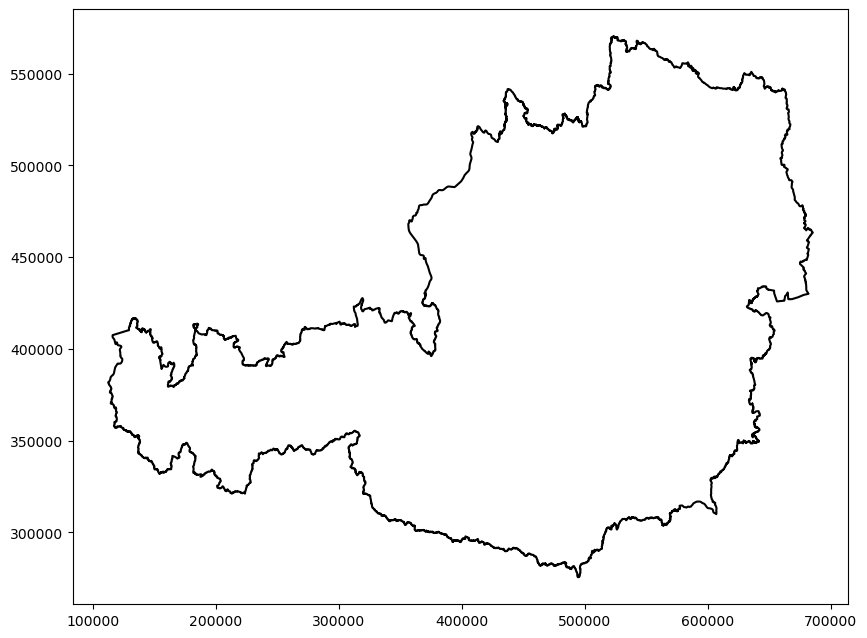

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))
austria_polygon_gdf.boundary.plot(ax=ax, color="black")
cross_border_lines.plot(ax=ax, color="blue", label="from .nc")
true_cross_border_lines.plot(ax=ax, color="red", label="from shapefile")
plt.legend()
plt.title("Visual comparison of line locations")
plt.show()


In [34]:
import pypsa
import geopandas as gpd
from shapely.wkt import dumps as wkt_dumps

# Load the PyPSA network
network = pypsa.Network("../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc")

# Convert bus locations to GeoDataFrame
bus_gdf = gpd.GeoDataFrame(
    network.buses,
    geometry=gpd.points_from_xy(network.buses.x, network.buses.y),
    crs="EPSG:4326"
)

# Create LineStrings for links between buses
def line_geometry(row):
    bus0 = bus_gdf.loc[row["bus0"]].geometry
    bus1 = bus_gdf.loc[row["bus1"]].geometry
    return LineString([bus0, bus1])

link_lines = network.links[["bus0", "bus1"]].copy()
link_lines["geometry"] = link_lines.apply(line_geometry, axis=1)
link_gdf = gpd.GeoDataFrame(link_lines, geometry="geometry", crs="EPSG:4326")

# Filter cross-border links: one bus in Austria, one outside
# You can define Austria by bounding box or polygon
austria_bbox = (9, 46, 17, 49)  # approx (minx, miny, maxx, maxy)

def is_in_austria(point):
    return (
        austria_bbox[0] <= point.x <= austria_bbox[2]
        and austria_bbox[1] <= point.y <= austria_bbox[3]
    )

def is_cross_border(row):
    p0 = bus_gdf.loc[row["bus0"]].geometry
    p1 = bus_gdf.loc[row["bus1"]].geometry
    return is_in_austria(p0) != is_in_austria(p1)

link_gdf["is_cross_border"] = link_gdf.apply(is_cross_border, axis=1)
cross_border_pypsa = link_gdf[link_gdf["is_cross_border"]]

# Save to CSV
cross_border_pypsa["wkt"] = cross_border_pypsa.geometry.apply(wkt_dumps)
cross_border_pypsa[["bus0", "bus1", "wkt"]].to_csv("cross_border_lines_pypsa.csv", index=False)


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


In [36]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString

# Load the shapefile (assumes the .shp and associated files are in the same folder)
gdf = gpd.read_file("qgis/NETZ_AUT.shp")

print("Loaded shapefile with", len(gdf), "features")

# Inspect attribute columns to see how we can identify cross-border lines
print("Columns:", gdf.columns)
print(gdf.head())

# Optional: check CRS
print("CRS:", gdf.crs)

# --- STEP 1: FILTER CROSS-BORDER LINES ---
# Strategy: check if the line crosses Austria’s boundary
# If there is an attribute marking foreign connections (e.g., 'from_country', 'to_country') use that
# Otherwise we can detect geometries that go outside Austria manually

# For now let's assume lines with 'AUT' in one column and not 'AUT' in the other are cross-border
cross_border = gdf[
    (gdf["from_country"] == "AUT") & (gdf["to_country"] != "AUT") |
    (gdf["from_country"] != "AUT") & (gdf["to_country"] == "AUT")
]

print("Identified", len(cross_border), "cross-border lines")

# --- STEP 2: Convert geometry to WKT and export ---
cross_border["wkt"] = cross_border.geometry.apply(lambda g: g.wkt)
cross_border.drop(columns=["geometry"], inplace=True)

cross_border.to_csv("cross_border_lines_qgis.csv", index=False)
print("✅ Exported to cross_border_lines_qgis.csv")


DataSourceError: qgis/NETZ_AUT.shp: No such file or directory

In [37]:
print(gdf.columns)
print(gdf.head())


NameError: name 'gdf' is not defined

In [38]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString

# Step 1: Load network lines and national border
lines = gpd.read_file("qgis/lines_aut.shp")
border = gpd.read_file("qgis/Grenze.shp")

# Step 2: Check and align CRS
if lines.crs != border.crs:
    border = border.to_crs(lines.crs)

# Step 3: Combine border geometries into a single polygon
austria = border.unary_union

# Step 4: Filter lines that intersect the border and extend outside
def is_cross_border(line):
    return line.intersects(austria) and not line.within(austria)

cross_border_lines = lines[lines.geometry.apply(is_cross_border)]

# Optional: log or check sample
print(f"Identified {len(cross_border_lines)} cross-border lines")

# Step 5: Export to CSV
cross_border_lines["wkt"] = cross_border_lines.geometry.apply(lambda g: g.wkt)
cross_border_lines.drop(columns=["geometry"], inplace=True)

cross_border_lines.to_csv("cross_border_lines_qgis.csv", index=False)
print("✅ Exported to cross_border_lines_qgis.csv")


/tmp/ipykernel_1275714/1733816953.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  austria = border.unary_union


AttributeError: 'NoneType' object has no attribute 'intersects'

In [39]:
import geopandas as gpd
import pandas as pd

# Load shapefiles
lines = gpd.read_file("qgis/lines_aut.shp")
border = gpd.read_file("qgis/Grenze.shp")

# Ensure CRS match
if lines.crs != border.crs:
    border = border.to_crs(lines.crs)

# Determine Austrian geometry
austria_geom = border.unary_union

# Extract country codes from node names
def extract_country_code(node):
    if isinstance(node, str) and len(node) >= 2:
        return node[:2]
    return None

lines["from_cc"] = lines["from_node"].apply(extract_country_code)
lines["to_cc"] = lines["to_node"].apply(extract_country_code)

# Define cross-border lines: one end AT, one end not AT
cross_border = lines[
    ((lines["from_cc"] == "AT") & (lines["to_cc"] != "AT")) |
    ((lines["from_cc"] != "AT") & (lines["to_cc"] == "AT"))
]

# Save to CSV with geometry as WKT
cross_border["wkt"] = cross_border.geometry.apply(lambda g: g.wkt)
cross_border.drop(columns=["geometry"], inplace=True)
cross_border.to_csv("cross_border_lines_qgis.csv", index=False)

print(f"✅ Found {len(cross_border)} cross-border lines and saved to CSV.")


✅ Found 0 cross-border lines and saved to CSV.


/tmp/ipykernel_1275714/277956415.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  austria_geom = border.unary_union
/tmp/ipykernel_1275714/277956415.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cross_border.drop(columns=["geometry"], inplace=True)


In [41]:
print("From node prefixes:")
print(lines["from_node"].dropna().str[:2].value_counts())

print("\nTo node prefixes:")
print(lines["to_node"].dropna().str[:2].value_counts())


From node prefixes:


AttributeError: Can only use .str accessor with string values!

In [42]:
from shapely.geometry import LineString

# Keep only lines that intersect Austria, but are not fully contained in it
intersects = lines[lines.geometry.intersects(austria_geom)]
not_within = intersects[~intersects.geometry.within(austria_geom)]

cross_border = not_within.copy()
cross_border["wkt"] = cross_border.geometry.apply(lambda g: g.wkt)
cross_border.drop(columns=["geometry"], inplace=True)
cross_border.to_csv("cross_border_lines_qgis_spatial.csv", index=False)

print(f"✅ Found {len(cross_border)} spatially detected cross-border lines and saved to CSV.")


✅ Found 59 spatially detected cross-border lines and saved to CSV.


In [43]:
print("From node prefixes:")
print(lines["from_node"].dropna().astype(str).str[:2].value_counts())

print("\nTo node prefixes:")
print(lines["to_node"].dropna().astype(str).str[:2].value_counts())


From node prefixes:
from_node
13    428
14    312
16    255
17    176
12    145
19    136
11    106
15     80
18     71
27     46
24     38
33     35
23     32
28     29
37     19
34     19
22     17
39     14
26     13
36     12
35      9
20      8
29      8
31      8
30      7
25      7
38      3
21      2
32      1
Name: count, dtype: int64

To node prefixes:
to_node
13    419
14    317
16    259
17    168
19    148
12    144
11    106
18     75
15     75
27     38
24     36
33     26
28     24
23     24
30     24
20     20
39     20
22     19
90     15
35     14
26     13
36     11
25     10
31      8
37      8
34      5
29      3
21      2
32      2
38      2
10      1
Name: count, dtype: int64


In [45]:
import geopandas as gpd
from shapely.geometry import LineString

# Load the Austria shapefile (used for borders)
border = gpd.read_file("qgis/Grenze.shp")
austria_geom = border[border["ADMIN"] == "Austria"].geometry.unary_union

# Load the line shapefile
lines = gpd.read_file("qgis/NETZ_AUT.shp")

# Ensure geometry is valid
lines = lines[lines.geometry.notnull()]

# Keep only lines that intersect Austria's border, but are not fully inside it
intersects = lines[lines.geometry.intersects(austria_geom)]
not_within = intersects[~intersects.geometry.within(austria_geom)]

# Save results
cross_border = not_within.copy()
cross_border["wkt"] = cross_border.geometry.apply(lambda g: g.wkt)
cross_border.drop(columns=["geometry"], inplace=True)
cross_border.to_csv("cross_border_lines_qgis_spatial.csv", index=False)

print(f"✅ Found {len(cross_border)} spatially detected cross-border lines and saved to CSV.")


KeyError: 'ADMIN'

In [46]:
import geopandas as gpd
import pandas as pd

# Load shapefiles
lines = gpd.read_file("qgis/lines_aut.shp")
border = gpd.read_file("qgis/Grenze.shp")

# Ensure CRS match
if lines.crs != border.crs:
    border = border.to_crs(lines.crs)

# Determine Austrian geometry
austria_geom = border.unary_union

# --- Filter only 380kV lines ---
# Adjust column name below if necessary (e.g., "voltage", "kv", etc.)
lines_380kv = lines[lines["v_ref"] == 380]

# Extract country codes from node names
def extract_country_code(node):
    if isinstance(node, str) and len(node) >= 2:
        return node[:2]
    return None

lines_380kv["from_cc"] = lines_380kv["from_node"].apply(extract_country_code)
lines_380kv["to_cc"] = lines_380kv["to_node"].apply(extract_country_code)

# --- Cross-border by node prefix ---
prefix_cross_border = lines_380kv[
    ((lines_380kv["from_cc"] == "AT") & (lines_380kv["to_cc"] != "AT")) |
    ((lines_380kv["from_cc"] != "AT") & (lines_380kv["to_cc"] == "AT"))
]

prefix_cross_border["wkt"] = prefix_cross_border.geometry.apply(lambda g: g.wkt)
prefix_cross_border.drop(columns=["geometry"], inplace=True)
prefix_cross_border.to_csv("cross_border_lines_qgis_prefix_380kv.csv", index=False)
print(f"✅ Found {len(prefix_cross_border)} prefix-based 380kV cross-border lines and saved to CSV.")

# --- Cross-border by spatial geometry ---
intersects = lines_380kv[lines_380kv.geometry.intersects(austria_geom)]
not_within = intersects[~intersects.geometry.within(austria_geom)]

spatial_cross_border = not_within.copy()
spatial_cross_border["wkt"] = spatial_cross_border.geometry.apply(lambda g: g.wkt)
spatial_cross_border.drop(columns=["geometry"], inplace=True)
spatial_cross_border.to_csv("cross_border_lines_qgis_spatial_380kv.csv", index=False)
print(f"✅ Found {len(spatial_cross_border)} spatially detected 380kV cross-border lines and saved to CSV.")


✅ Found 0 prefix-based 380kV cross-border lines and saved to CSV.
✅ Found 17 spatially detected 380kV cross-border lines and saved to CSV.


/tmp/ipykernel_1275714/2250913818.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  austria_geom = border.unary_union
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__

/tmp/ipykernel_1275714/3760925549.py:5: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  lines[lines.id.isin(prefix_cross_border["id"])].plot(ax=base, color='red', linewidth=1.5)


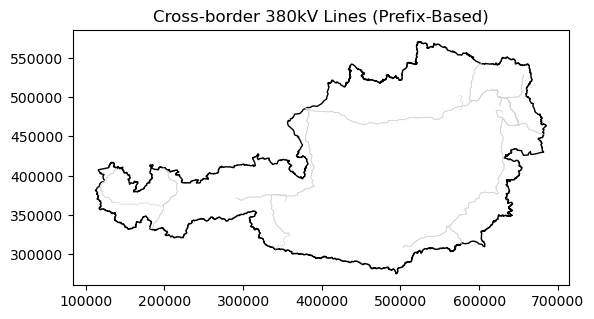

In [47]:
import matplotlib.pyplot as plt

base = border.plot(color='white', edgecolor='black')
lines_380kv.plot(ax=base, color='lightgray', linewidth=0.5)
lines[lines.id.isin(prefix_cross_border["id"])].plot(ax=base, color='red', linewidth=1.5)
plt.title("Cross-border 380kV Lines (Prefix-Based)")
plt.show()


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


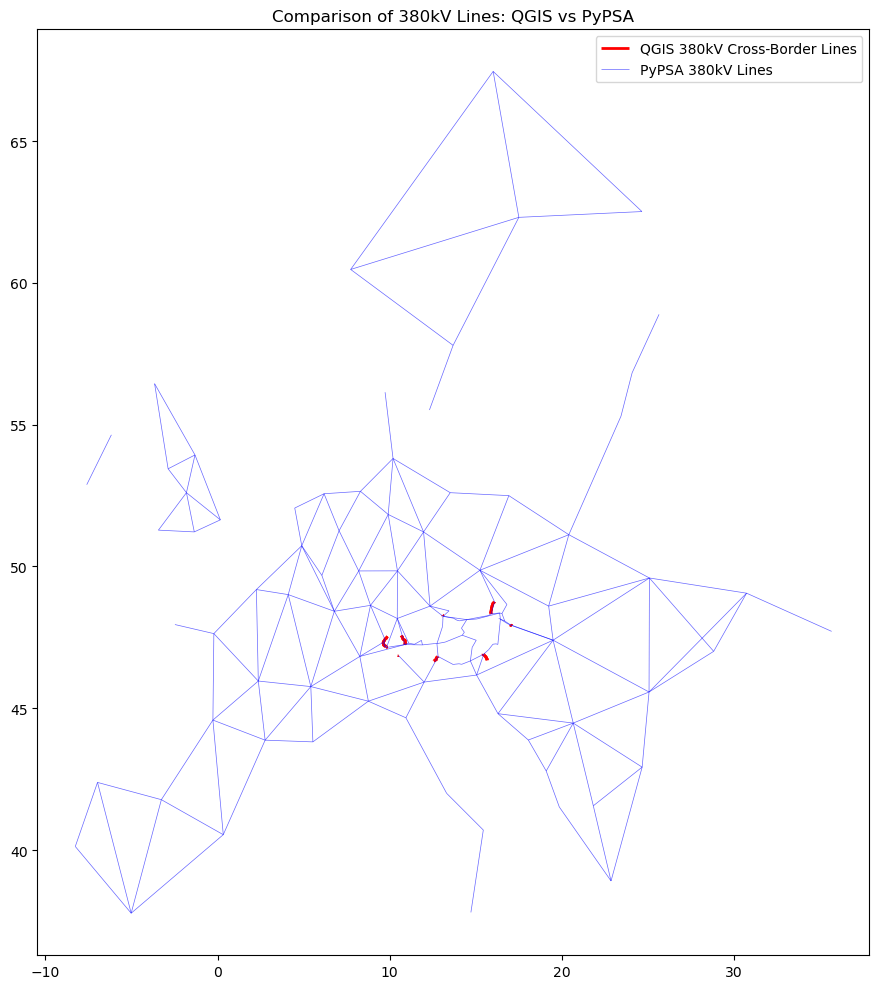

In [50]:
import pypsa
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import LineString


# Load PyPSA network
nc_path = "../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc"
n = pypsa.Network(nc_path)

# Load CSV with 380kV lines
csv_path = "cross_border_lines_qgis_spatial_380kv.csv"
cross_border_lines = pd.read_csv(csv_path)
cross_border_lines["geometry"] = cross_border_lines["wkt"].apply(wkt.loads)
cross_border_gdf = gpd.GeoDataFrame(cross_border_lines, geometry="geometry", crs="EPSG:31287")  # MGI / Austria Lambert

# Convert to common CRS
target_crs = "EPSG:4326"
cross_border_gdf = cross_border_gdf.to_crs(target_crs)

# Extract 380kV lines from PyPSA network
lines_380kv_pypsa = n.lines[n.lines.v_nom == 380]
buses = n.buses[["x", "y"]]

# Build GeoDataFrame for PyPSA lines
geoms = []
for idx, line in lines_380kv_pypsa.iterrows():
    bus0 = buses.loc[line.bus0]
    bus1 = buses.loc[line.bus1]
    geoms.append({
        "name": idx,
        #"geometry": gpd.points_from_xy([bus0.x, bus1.x], [bus0.y, bus1.y]).unary_union
        "geometry": LineString([(bus0.x, bus0.y), (bus1.x, bus1.y)])
    })
pypsa_lines_gdf = gpd.GeoDataFrame(geoms, crs="EPSG:4326")

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))
cross_border_gdf.plot(ax=ax, color="red", linewidth=2, label="QGIS 380kV Cross-Border Lines")
pypsa_lines_gdf.plot(ax=ax, color="blue", linewidth=0.5, alpha=0.6, label="PyPSA 380kV Lines")
ax.legend()
ax.set_title("Comparison of 380kV Lines: QGIS vs PyPSA")
plt.tight_layout()
plt.show()


In [51]:
border = gpd.read_file("qgis/Grenze.shp")


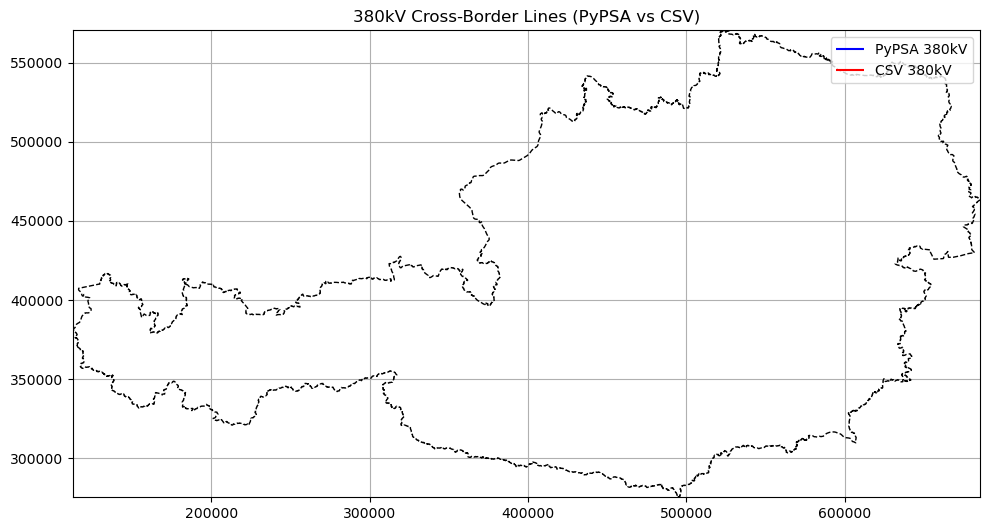

In [52]:
# Get bounding box of Austria
austria_bounds = border.total_bounds  # [minx, miny, maxx, maxy]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
pypsa_lines_gdf.plot(ax=ax, color="blue", label="PyPSA 380kV")
cross_border_gdf.plot(ax=ax, color="red", label="CSV 380kV")

# Add Austria border for context
border.boundary.plot(ax=ax, color="black", linewidth=1, linestyle="--")

# Set extent to Austria
ax.set_xlim(austria_bounds[0], austria_bounds[2])
ax.set_ylim(austria_bounds[1], austria_bounds[3])

# Add legend and grid
ax.legend()
ax.set_title("380kV Cross-Border Lines (PyPSA vs CSV)")
ax.grid(True)
plt.tight_layout()
plt.show()


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


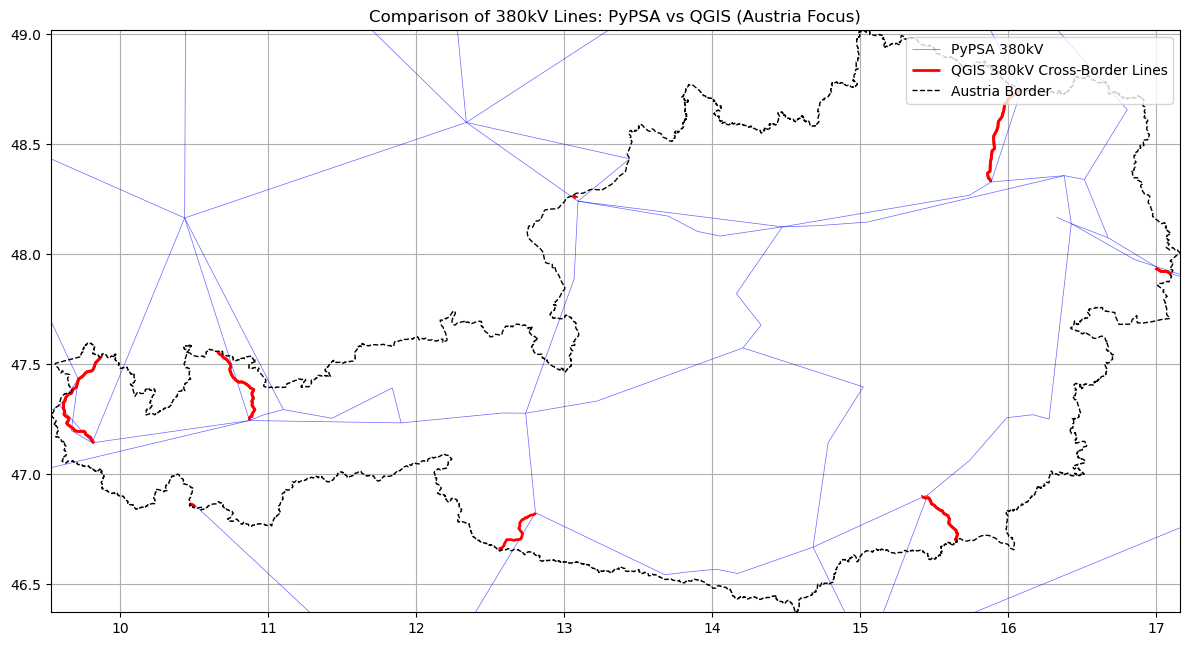

In [53]:
import pypsa
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import LineString

# --- Load Data ---

# PyPSA network
nc_path = "../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc"
n = pypsa.Network(nc_path)

# Cross-border lines from QGIS
csv_path = "cross_border_lines_qgis_spatial_380kv.csv"
cross_border_lines = pd.read_csv(csv_path)
cross_border_lines["geometry"] = cross_border_lines["wkt"].apply(wkt.loads)
cross_border_gdf = gpd.GeoDataFrame(cross_border_lines, geometry="geometry", crs="EPSG:31287")
cross_border_gdf = cross_border_gdf.to_crs("EPSG:4326")

# Austria border for plotting extent
border = gpd.read_file("qgis/Grenze.shp").to_crs("EPSG:4326")
austria_bounds = border.total_bounds  # [minx, miny, maxx, maxy]

# --- Extract and Convert PyPSA 380kV Lines ---

lines_380kv_pypsa = n.lines[n.lines.v_nom == 380]
buses = n.buses[["x", "y"]]

geoms = []
for idx, line in lines_380kv_pypsa.iterrows():
    bus0 = buses.loc[line.bus0]
    bus1 = buses.loc[line.bus1]
    geoms.append({
        "name": idx,
        "geometry": LineString([(bus0.x, bus0.y), (bus1.x, bus1.y)])
    })

pypsa_lines_gdf = gpd.GeoDataFrame(geoms, crs="EPSG:4326")

# --- Plotting ---

fig, ax = plt.subplots(figsize=(12, 10))

# Plot each layer
pypsa_lines_gdf.plot(ax=ax, color="blue", linewidth=0.5, alpha=0.6, label="PyPSA 380kV")
cross_border_gdf.plot(ax=ax, color="red", linewidth=2, label="QGIS 380kV Cross-Border Lines")
border.boundary.plot(ax=ax, color="black", linewidth=1, linestyle="--", label="Austria Border")

# Set extent to Austria
ax.set_xlim(austria_bounds[0], austria_bounds[2])
ax.set_ylim(austria_bounds[1], austria_bounds[3])

# Finishing touches
ax.set_title("Comparison of 380kV Lines: PyPSA vs QGIS (Austria Focus)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [54]:
!pip install contextily

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1275714) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()
82174.93s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


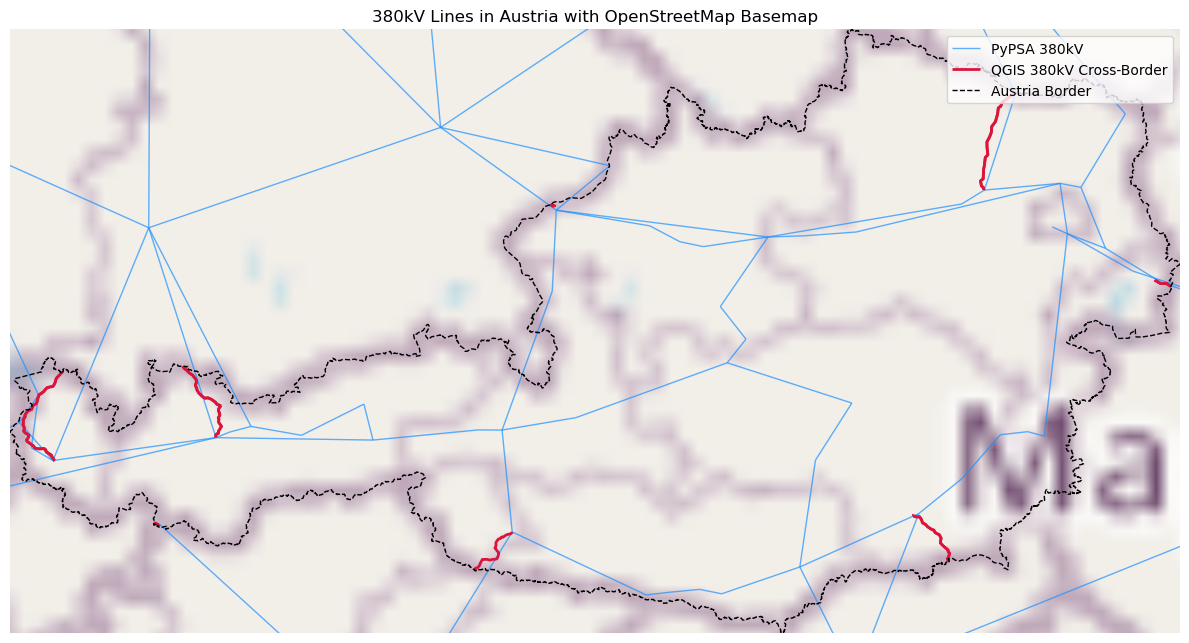

In [55]:
import pypsa
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import LineString
import contextily as cx

# --- Load Data ---

# PyPSA network
nc_path = "../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc"
n = pypsa.Network(nc_path)

# QGIS 380kV CSV
csv_path = "cross_border_lines_qgis_spatial_380kv.csv"
cross_border_lines = pd.read_csv(csv_path)
cross_border_lines["geometry"] = cross_border_lines["wkt"].apply(wkt.loads)
cross_border_gdf = gpd.GeoDataFrame(cross_border_lines, geometry="geometry", crs="EPSG:31287")
cross_border_gdf = cross_border_gdf.to_crs("EPSG:3857")  # Web Mercator for basemaps

# Austria border
border = gpd.read_file("qgis/Grenze.shp").to_crs("EPSG:3857")
austria_bounds = border.total_bounds

# --- PyPSA 380kV lines to GeoDataFrame ---

lines_380kv_pypsa = n.lines[n.lines.v_nom == 380]
buses = n.buses[["x", "y"]]

geoms = []
for idx, line in lines_380kv_pypsa.iterrows():
    bus0 = buses.loc[line.bus0]
    bus1 = buses.loc[line.bus1]
    geoms.append({
        "name": idx,
        "geometry": LineString([(bus0.x, bus0.y), (bus1.x, bus1.y)])
    })

pypsa_lines_gdf = gpd.GeoDataFrame(geoms, crs="EPSG:4326").to_crs("EPSG:3857")

# --- Plotting with basemap ---

fig, ax = plt.subplots(figsize=(12, 10))

pypsa_lines_gdf.plot(ax=ax, color="dodgerblue", linewidth=1, alpha=0.7, label="PyPSA 380kV")
cross_border_gdf.plot(ax=ax, color="crimson", linewidth=2, label="QGIS 380kV Cross-Border")
border.boundary.plot(ax=ax, edgecolor="black", linestyle="--", linewidth=1, label="Austria Border")

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, attribution=False)

# Zoom to Austria
ax.set_xlim(austria_bounds[0], austria_bounds[2])
ax.set_ylim(austria_bounds[1], austria_bounds[3])

# Final touches
ax.set_title("380kV Lines in Austria with OpenStreetMap Basemap")
ax.legend()
ax.axis("off")  # turn off axis for cleaner map
plt.tight_layout()
plt.show()


In [2]:
%pip install geodatasets


  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
Note: you may need to restart the kernel to use updated packages.


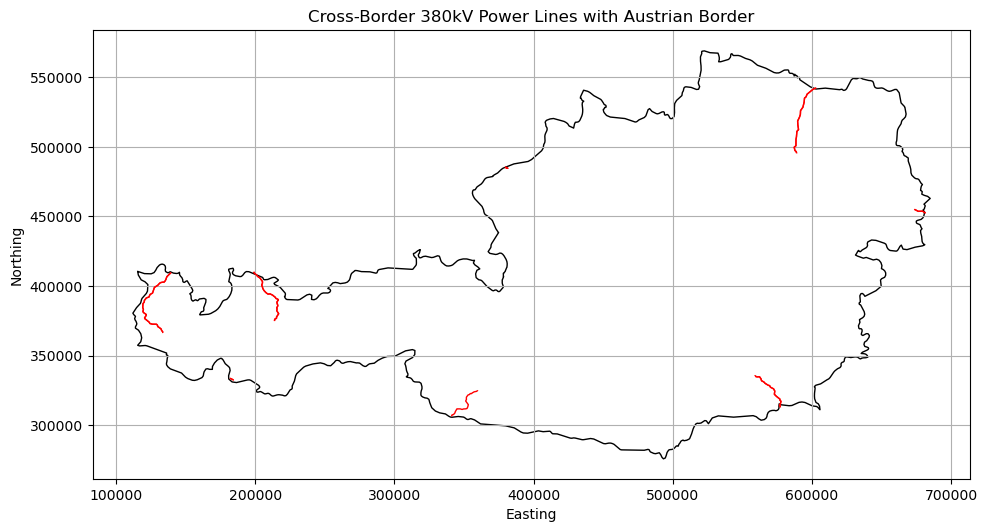

In [10]:
#21.04.2025 load spatial csv 380 kv and plot

import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

import geodatasets



# Load the CSV file
file_path = 'cross_border_lines_qgis_spatial_380kv.csv'  # Adjust path if needed
df = pd.read_csv(file_path)

# Convert WKT column to shapely geometries
df['geometry'] = df['wkt'].apply(wkt.loads)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the appropriate CRS (assuming EPSG:31287 - Austria Lambert)
gdf.set_crs(epsg=31287, inplace=True)

# Load world borders and filter Austria
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
#austria = world[world.name == 'Austria'].to_crs(gdf.crs)
#world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
#austria = world[world['name'] == 'Austria'].to_crs(gdf.crs)
# Load countries instead of land
#countries_path = geodatasets.get_path('naturalearth.countries')
#countries_path = geodatasets.get_path("naturalearth.admin_0_countries")
#countries_path = geodatasets.get_path("naturalearth.ne_10m_admin_0_sovereignty")

#countries_path = geodatasets.get_path("geoda austria")

#world = gpd.read_file(countries_path)
# Load shapefile from downloaded Natural Earth countries
world = gpd.read_file("data/ne_10m_admin_0_sovereignty.shp")
austria = world[world["ADMIN"] == "Austria"].to_crs(gdf.crs)
# Filter for Austria
austria = world[world['ADMIN'] == 'Austria'].to_crs(gdf.crs)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
austria.plot(ax=ax, color='white', edgecolor='black')
gdf.plot(ax=ax, color='red', linewidth=1)
plt.title("Cross-Border 380kV Power Lines with Austrian Border")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
print("Bounds of power lines:", gdf.total_bounds)
print("Bounds of Austria:", austria.total_bounds)


Bounds of power lines: [119174.49898139 306438.66429724 681603.21830649 542464.68866574]
Bounds of Austria: [111750.84682908 276148.33309757 684524.63797669 569209.40576803]


In [12]:
gdf_wgs = gdf.to_crs(epsg=4326)
austria_wgs = austria.to_crs(epsg=4326)


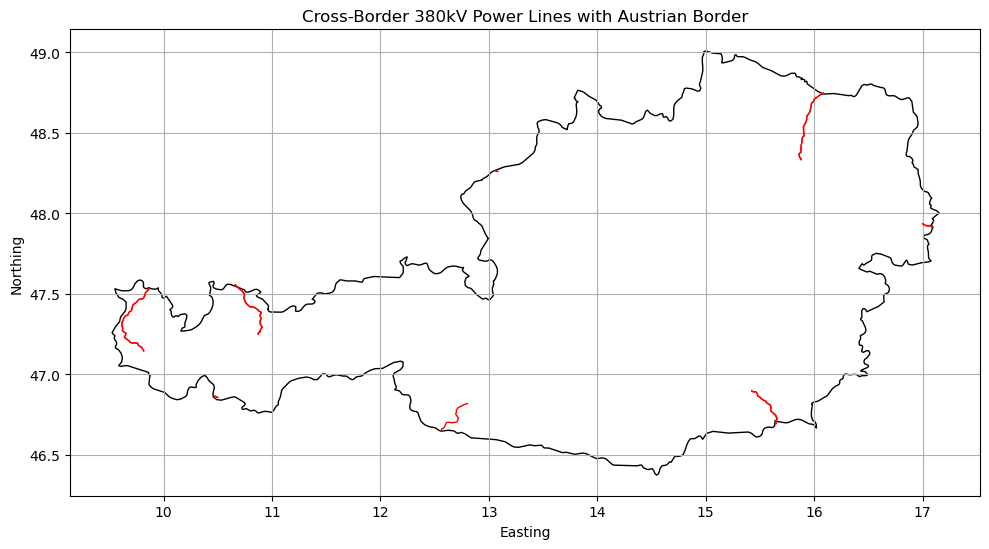

In [13]:

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
austria_wgs.plot(ax=ax, color='white', edgecolor='black')
gdf_wgs.plot(ax=ax, color='red', linewidth=1)
plt.title("Cross-Border 380kV Power Lines with Austrian Border")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
print("Total lines:", len(gdf))
print("Valid lines:", gdf.geometry.is_valid.sum())
print("Non-empty lines:", gdf.geometry.notnull().sum())


Total lines: 17
Valid lines: 17
Non-empty lines: 17


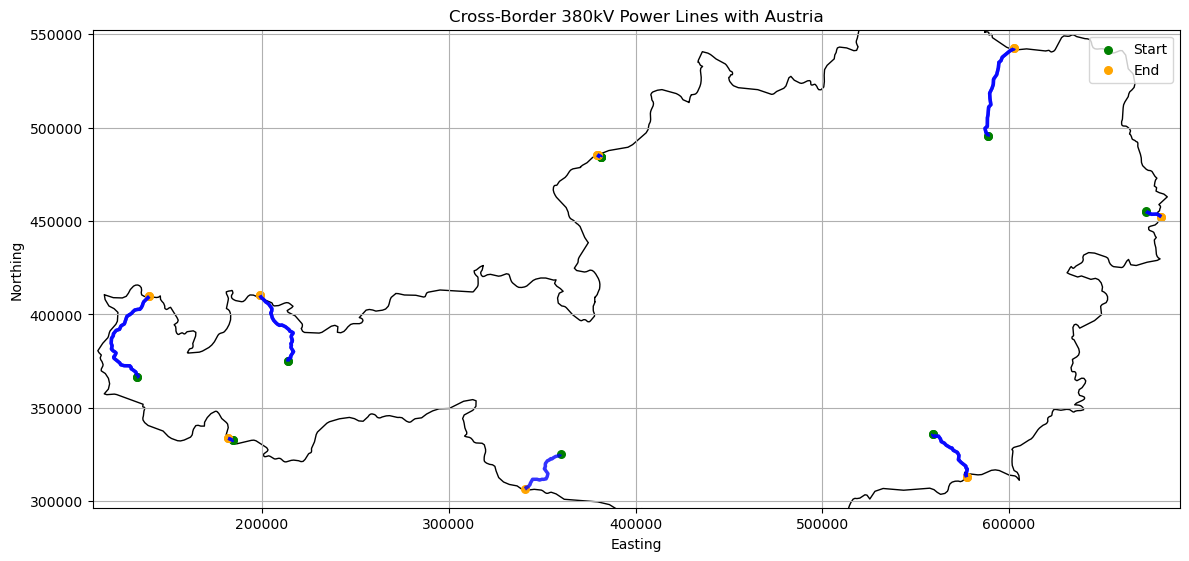

In [15]:
import matplotlib.pyplot as plt

# Basic plot setup
fig, ax = plt.subplots(figsize=(12, 12))

# Plot Austria border
austria.plot(ax=ax, color="white", edgecolor="black")

# Plot power lines with thicker width and standout color
gdf.plot(ax=ax, color="blue", linewidth=2.5, alpha=0.8)

# Optionally: plot the start/end points of each line
endpoints = gdf.copy()
endpoints["start"] = endpoints.geometry.apply(lambda x: x.coords[0])
endpoints["end"] = endpoints.geometry.apply(lambda x: x.coords[-1])

# Convert start/end to Point geometry
from shapely.geometry import Point
start_points = gpd.GeoDataFrame(geometry=endpoints["start"].apply(Point), crs=gdf.crs)
end_points = gpd.GeoDataFrame(geometry=endpoints["end"].apply(Point), crs=gdf.crs)

start_points.plot(ax=ax, color="green", markersize=30, label="Start")
end_points.plot(ax=ax, color="orange", markersize=30, label="End")

# Zoom out a bit to ensure all lines are visible
ax.set_xlim(gdf.total_bounds[0] - 10000, gdf.total_bounds[2] + 10000)
ax.set_ylim(gdf.total_bounds[1] - 10000, gdf.total_bounds[3] + 10000)

# Final plot touches
plt.title("Cross-Border 380kV Power Lines with Austria")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


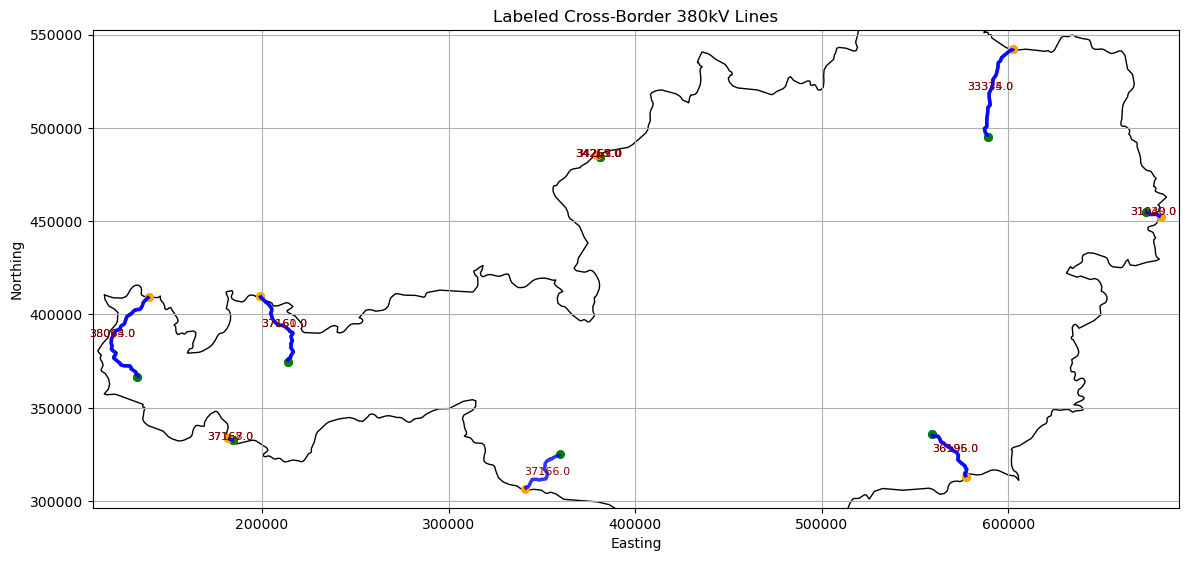

In [16]:
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Plot setup
fig, ax = plt.subplots(figsize=(12, 12))

# Plot Austria
austria.plot(ax=ax, color="white", edgecolor="black")

# Plot power lines
gdf.plot(ax=ax, color="blue", linewidth=2.5, alpha=0.8)

# Plot start/end points
endpoints = gdf.copy()
endpoints["start"] = endpoints.geometry.apply(lambda x: x.coords[0])
endpoints["end"] = endpoints.geometry.apply(lambda x: x.coords[-1])
start_points = gpd.GeoDataFrame(geometry=endpoints["start"].apply(Point), crs=gdf.crs)
end_points = gpd.GeoDataFrame(geometry=endpoints["end"].apply(Point), crs=gdf.crs)
start_points.plot(ax=ax, color="green", markersize=30)
end_points.plot(ax=ax, color="orange", markersize=30)

# 📍 Add labels at line midpoints
gdf["midpoint"] = gdf.geometry.interpolate(0.5, normalized=True)
for idx, row in gdf.iterrows():
    label = row.get("id", f"Line {idx+1}")  # Use 'id' or fallback to Line 1, Line 2...
    x, y = row["midpoint"].x, row["midpoint"].y
    ax.text(x, y, str(label), fontsize=8, color="darkred", ha="center")

# Adjust plot limits to fit everything
ax.set_xlim(gdf.total_bounds[0] - 10000, gdf.total_bounds[2] + 10000)
ax.set_ylim(gdf.total_bounds[1] - 10000, gdf.total_bounds[3] + 10000)

# Title and grid
plt.title("Labeled Cross-Border 380kV Lines")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.grid(True)
plt.tight_layout()
plt.show()


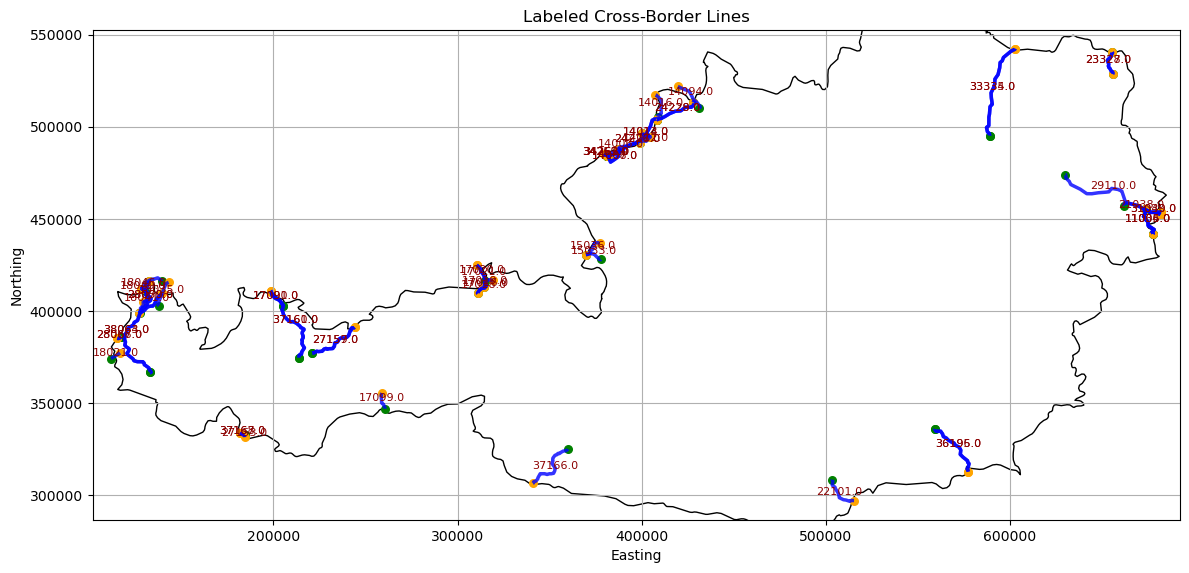

In [17]:
### now use the unfiltered cross border lines

import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load the CSV file
file_path = 'cross_border_lines_qgis_spatial.csv'  # Adjust path if needed
df = pd.read_csv(file_path)

# Convert WKT column to shapely geometries
df['geometry'] = df['wkt'].apply(wkt.loads)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the appropriate CRS (assuming EPSG:31287 - Austria Lambert)
gdf.set_crs(epsg=31287, inplace=True)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 12))

# Plot Austria
austria.plot(ax=ax, color="white", edgecolor="black")

# Plot power lines
gdf.plot(ax=ax, color="blue", linewidth=2.5, alpha=0.8)

# Plot start/end points
endpoints = gdf.copy()
endpoints["start"] = endpoints.geometry.apply(lambda x: x.coords[0])
endpoints["end"] = endpoints.geometry.apply(lambda x: x.coords[-1])
start_points = gpd.GeoDataFrame(geometry=endpoints["start"].apply(Point), crs=gdf.crs)
end_points = gpd.GeoDataFrame(geometry=endpoints["end"].apply(Point), crs=gdf.crs)
start_points.plot(ax=ax, color="green", markersize=30)
end_points.plot(ax=ax, color="orange", markersize=30)

# 📍 Add labels at line midpoints
gdf["midpoint"] = gdf.geometry.interpolate(0.5, normalized=True)
for idx, row in gdf.iterrows():
    label = row.get("id", f"Line {idx+1}")  # Use 'id' or fallback to Line 1, Line 2...
    x, y = row["midpoint"].x, row["midpoint"].y
    ax.text(x, y, str(label), fontsize=8, color="darkred", ha="center")

# Adjust plot limits to fit everything
ax.set_xlim(gdf.total_bounds[0] - 10000, gdf.total_bounds[2] + 10000)
ax.set_ylim(gdf.total_bounds[1] - 10000, gdf.total_bounds[3] + 10000)

# Title and grid
plt.title("Labeled Cross-Border Lines")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.grid(True)
plt.tight_layout()
plt.show()
